# Experiment 2 — Color Discrimination Test

**Replication of Reinecke, Flatla & Brooks, *Enabling Designers to Foresee Which Colors Users Cannot See* (CHI 2016), with a color-practice extension.**

This notebook is analysis material for *Ten Years Later: Replicating Two Color Discrimination Studies*. It reproduces the analysis of Experiment 2 (Sec. 4 of the paper):

- **Part A — Replication.** Participants identified the gap direction of a colored Landolt-C on a gray background while an iterated binary search adjusted the color along one of four recovered axes (pink, magenta, blue, lighter) until it converged on the discrimination threshold. Following the original study, we average each participant's thresholds per color, reconstruct a **discrimination ellipsoid** in CIE L\*u\*v\* space, and compare the ellipsoid-volume distribution with the original study's.
- **Part B — Extension.** We partition participants into **Known Color Practice** and **Unknown Color Practice** groups from the same post-study questionnaires as Experiment 1 and test whether color practice affects discrimination.

**Data.** The gitignored ReVISit exports must be present in `analysis/exp2/static/color-vision-data/`: `color-vision-perception_{male,female}.json`. The analysis pipeline lives in `analysis/python/color_analysis/` and mirrors the TypeScript implementation of the interactive dashboard (`analysis/exp2/`).

**Run.** From `analysis/`: `uv sync`, then `uv run jupyter lab exp2/results.ipynb` (or `uv run jupyter execute exp2/results.ipynb`).

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from color_analysis.exp2 import (
    EXPERT_COLOR,
    HISTOGRAM_BIN_WIDTH,
    HISTOGRAM_MAX_VOLUME,
    MAX_LOCATION_BY_VECTOR,
    NON_EXPERT_COLOR,
    NORMALITY_EXPERT_COLOR,
    NORMALITY_NON_EXPERT_COLOR,
    ORIGINAL_STUDY_VOLUME_SUMMARY,
    PAPER_VOLUME_BAR_FILL,
    PAPER_VOLUME_BAR_STROKE,
    PAPER_VOLUME_INK,
    RECOVERED_AXES,
    STUDY_CURRENT_COLOR,
    STUDY_REFERENCE_COLOR,
    VECTOR_COLORS,
    VECTOR_NAMES,
    build_distribution_comparison,
    build_volume_equivalence_comparison,
    interpret_cohens_d,
    load_participant_groups,
    participant_records,
)
from color_analysis.exp2.group_analysis import build_group_analysis, metrics_dataframe
from color_analysis.expert_clause import (
    get_default_expert_clause,
    get_expert_clause_summary,
)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110

pd.set_option("display.precision", 4)


## 1. Load data and cohort overview

We load the male and female participant exports and extract per-participant metrics: staircase thresholds per vector, trial accuracy over all staircase guesses, and the reconstructed discrimination-ellipsoid volume.

In [12]:
groups = load_participant_groups()
all_participants = groups["male"] + groups["female"]

records_fitted = participant_records(all_participants, "include-fitted")
records_exact = participant_records(all_participants, "exact")

df = metrics_dataframe(records_fitted)
df_exact = metrics_dataframe(records_exact)

counts = pd.DataFrame(
    {
        "exported": [len(groups["male"]), len(groups["female"]),
                     len(groups["male"]) + len(groups["female"])],
    },
    index=["male", "female", "total"],
)

n_fitted_fallback = int((df["fitKind"] == "fitted").sum())
print(f"Participants analyzed: {len(df)}")
print(f"Mean trial accuracy:  {df['accuracy'].mean():.1%} (SD = {df['accuracy'].std(ddof=1):.1%})")
print(f"Mean raw threshold:   {df['meanRawThreshold'].mean():.2f} steps "
      f"(SD = {df['meanRawThreshold'].std(ddof=1):.2f})")
counts

Participants analyzed: 394
Mean trial accuracy:  60.1% (SD = 7.2%)
Mean raw threshold:   16.27 steps (SD = 8.68)


,exported
male,197
female,197
total,394


## Part A — Replication of Reinecke et al. (2016)

### 2. Staircase thresholds per color vector

Distributions of per-participant mean thresholds (in staircase steps from the background color) for the four recovered axes. Larger thresholds mean more color difference was needed to identify the Landolt-C's orientation.

In [13]:
order = [VECTOR_NAMES[v] for v in sorted(VECTOR_NAMES)]
threshold_rows = []
for record in records_fitted:
    for vector, mean_threshold in record["metric"]["thresholdMeans"].items():
        threshold_rows.append(
            {
                "participantId": record["participantId"],
                "vector": vector,
                "color": VECTOR_NAMES[vector],
                "mean_threshold": mean_threshold,
                "normalized": mean_threshold / MAX_LOCATION_BY_VECTOR[vector],
            }
        )
thresholds_df = pd.DataFrame(threshold_rows)

thresholds_df.groupby("color")["mean_threshold"].agg(["mean", "std", "median"]).reindex(order).round(2)

,mean,std,median
color,,,
pink,15.15,10.77,12.33
magenta,14.39,11.35,12.00
blue,20.24,14.52,17.33
lighter,15.28,5.31,14.00


### 3. Discrimination-ellipsoid volumes (paper Fig. 3)

Each participant's mean thresholds are converted into radii along the recovered L\*u\*v\* axes; the three chromatic radii define an ellipse in the u\*v\* plane and the lightness radius provides the third semi-axis. Volume $= \frac{4}{3}\pi\, a\, b\, c$, where larger volumes indicate poorer color discrimination.

We reproduce the website's paper-style Fig. 3 (`PaperVolumeDistributionFigure`): Tukey boxplot over a histogram (bin width 250, volumes above 12,000 omitted from the plot), percent labels on bars, and an inset five-number summary. The figure uses the **exact** ellipse mode (participants whose thresholds define a valid ellipse directly); the comparison table below also reports the fitted-fallback distribution that retains all participants. Sections 4–5 then reproduce the website's formal original-study checks (mean equivalence and full distribution comparison).

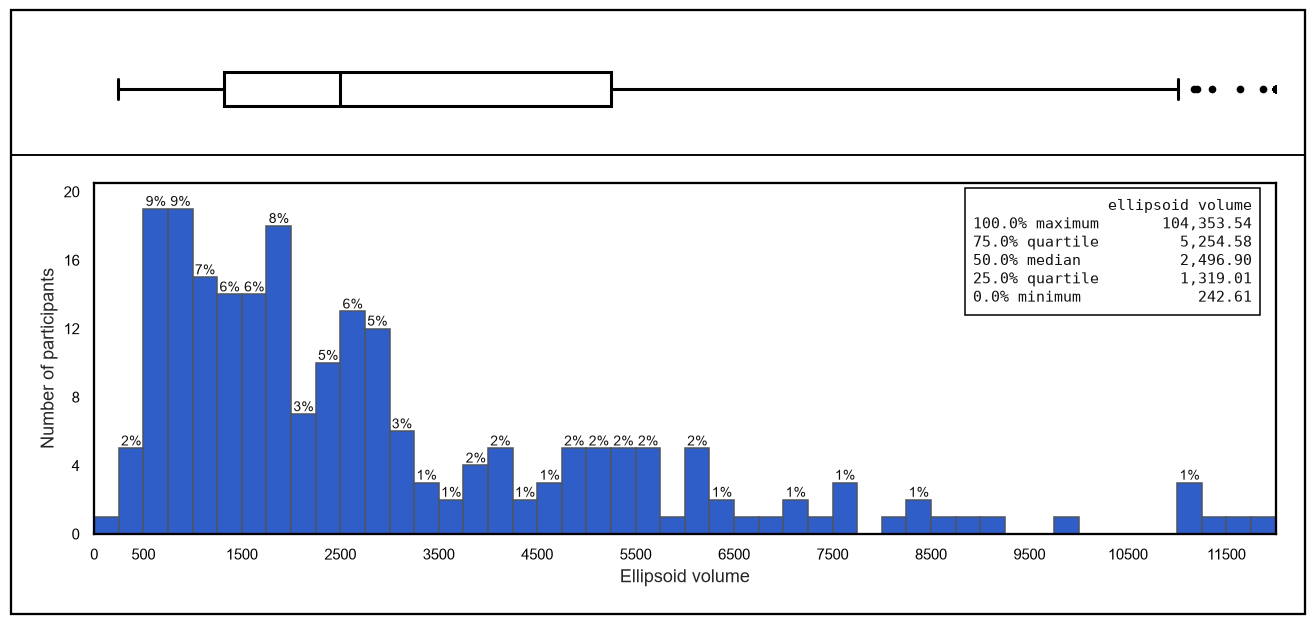

,our replication (exact),our replication (include-fitted),original study
minimum,242.61,1.8017e+02,2.1680e+01
firstQuartile,1319.01,1.4250e+03,8.0462e+02
median,2496.90,2.8485e+03,1.5584e+03
thirdQuartile,5254.58,5.6767e+03,3.2236e+03
maximum,104353.54,1.7825e+06,1.0584e+06


In [14]:
clause = get_default_expert_clause()
analysis = build_group_analysis(records_fitted, clause)
analysis_exact = build_group_analysis(records_exact, clause)

# PaperVolumeDistributionFigure.svelte (website paper-style Fig. 3), exact-ellipse mode.
volumes = np.sort(analysis_exact["volumes"])
summary = analysis_exact["volumeSummary"]
hist = analysis_exact["histogram"]
visible_count = int((volumes <= HISTOGRAM_MAX_VOLUME).sum())

iqr = summary["thirdQuartile"] - summary["firstQuartile"]
lower_fence = summary["firstQuartile"] - 1.5 * iqr
upper_fence = summary["thirdQuartile"] + 1.5 * iqr
non_outliers = volumes[(volumes >= lower_fence) & (volumes <= upper_fence)]
whisker_min = float(non_outliers[0]) if len(non_outliers) else summary["minimum"]
whisker_max = float(non_outliers[-1]) if len(non_outliers) else summary["maximum"]
outliers = volumes[(volumes < whisker_min) | (volumes > whisker_max)]


def _clamp_x(value: float) -> float:
    return min(value, HISTOGRAM_MAX_VOLUME)


def _show_x_label(value: float) -> bool:
    step = 500
    index = round(value / step)
    if abs(value - index * step) > 1e-6:
        return False
    if index in (0, 1):
        return True
    return index >= 3 and index % 2 == 1


with plt.rc_context({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
    "axes.edgecolor": PAPER_VOLUME_INK,
    "xtick.color": PAPER_VOLUME_INK,
    "ytick.color": PAPER_VOLUME_INK,
    "text.color": "#111111",
}):
    fig = plt.figure(figsize=(12, 5.6), facecolor="white")
    ax_box = fig.add_axes([0.073, 0.79, 0.895, 0.145])
    ax_hist = fig.add_axes([0.073, 0.14, 0.895, 0.57], sharex=ax_box)

    for ax in (ax_box, ax_hist):
        ax.set_facecolor("white")
        ax.grid(False)

    # Tukey boxplot (whiskers to last non-outlier; outliers as dots)
    box_y, box_h, cap_h = 0.5, 0.38, 0.22
    q1, q3, med = summary["firstQuartile"], summary["thirdQuartile"], summary["median"]
    ax_box.plot([_clamp_x(whisker_min), _clamp_x(q1)], [box_y, box_y], color=PAPER_VOLUME_INK, lw=2)
    ax_box.plot([_clamp_x(q3), _clamp_x(whisker_max)], [box_y, box_y], color=PAPER_VOLUME_INK, lw=2)
    for x in (_clamp_x(whisker_min), _clamp_x(whisker_max)):
        ax_box.plot([x, x], [box_y - cap_h / 2, box_y + cap_h / 2], color=PAPER_VOLUME_INK, lw=2)
    ax_box.add_patch(
        plt.Rectangle(
            (_clamp_x(q1), box_y - box_h / 2),
            max(1e-6, _clamp_x(q3) - _clamp_x(q1)),
            box_h,
            fill=True,
            facecolor="white",
            edgecolor=PAPER_VOLUME_INK,
            linewidth=2,
            zorder=2,
        )
    )
    ax_box.plot(
        [_clamp_x(med), _clamp_x(med)],
        [box_y - box_h / 2, box_y + box_h / 2],
        color=PAPER_VOLUME_INK,
        lw=2,
        zorder=3,
    )
    if len(outliers):
        ax_box.scatter(
            [_clamp_x(v) for v in outliers],
            np.full(len(outliers), box_y),
            s=16,
            c="black",
            zorder=4,
            clip_on=True,
        )
    ax_box.set_xlim(0, HISTOGRAM_MAX_VOLUME)
    ax_box.set_ylim(0, 1)
    ax_box.set_yticks([])
    ax_box.tick_params(axis="x", labelbottom=False, length=0)
    for spine in ax_box.spines.values():
        spine.set_visible(False)

    # Histogram with percent labels (≥ 1%)
    peak = max(1, int(hist["count"].max()))
    ax_hist.bar(
        hist["start"],
        hist["count"],
        width=HISTOGRAM_BIN_WIDTH,
        align="edge",
        color=PAPER_VOLUME_BAR_FILL,
        edgecolor=PAPER_VOLUME_BAR_STROKE,
        linewidth=1.0,
    )
    for start, count in zip(hist["start"], hist["count"]):
        pct = round(100 * count / visible_count) if visible_count else 0
        if pct >= 1:
            ax_hist.text(
                start + HISTOGRAM_BIN_WIDTH / 2,
                count,
                f"{pct}%",
                ha="center",
                va="bottom",
                fontsize=9,
                color="#111111",
            )
    ax_hist.set_xlim(0, HISTOGRAM_MAX_VOLUME)
    ax_hist.set_ylim(0, peak * 1.08)
    ax_hist.set_xlabel("Ellipsoid volume", fontsize=12)
    ax_hist.set_ylabel("Number of participants", fontsize=12)
    ax_hist.yaxis.set_major_locator(plt.MaxNLocator(6, integer=True))
    ticks = np.arange(0, HISTOGRAM_MAX_VOLUME + 500, 500)
    ax_hist.set_xticks(ticks)
    ax_hist.set_xticklabels([f"{int(t)}" if _show_x_label(t) else "" for t in ticks], fontsize=10)
    ax_hist.tick_params(axis="both", length=6, width=1.25, labelsize=10)
    for spine in ax_hist.spines.values():
        spine.set_color(PAPER_VOLUME_INK)
        spine.set_linewidth(1.5)

    # Inset five-number summary table
    table_rows = [
        ("100.0% maximum", summary["maximum"]),
        ("75.0% quartile", summary["thirdQuartile"]),
        ("50.0% median", summary["median"]),
        ("25.0% quartile", summary["firstQuartile"]),
        ("0.0% minimum", summary["minimum"]),
    ]
    table_text = "ellipsoid volume\n" + "\n".join(
        f"{label:<18} {value:>12,.2f}" for label, value in table_rows
    )
    ax_hist.text(
        0.98,
        0.96,
        table_text,
        transform=ax_hist.transAxes,
        ha="right",
        va="top",
        fontsize=10,
        family="monospace",
        bbox=dict(
            boxstyle="square,pad=0.55",
            facecolor="white",
            edgecolor=PAPER_VOLUME_INK,
            linewidth=1,
        ),
    )

    # Outer paper border + divider between panels
    fig.add_artist(
        plt.Rectangle(
            (0.01, 0.01),
            0.98,
            0.98,
            fill=False,
            edgecolor=PAPER_VOLUME_INK,
            linewidth=1.5,
            transform=fig.transFigure,
            zorder=10,
        )
    )
    fig.add_artist(
        plt.Line2D(
            [0.01, 0.99],
            [0.755, 0.755],
            transform=fig.transFigure,
            color=PAPER_VOLUME_INK,
            linewidth=1.25,
            zorder=10,
        )
    )
    plt.show()

comparison_table = pd.DataFrame(
    {
        "our replication (exact)": summary,
        "our replication (include-fitted)": analysis["volumeSummary"],
        "original study": ORIGINAL_STUDY_VOLUME_SUMMARY,
    }
).round(2)
comparison_table


### 5. Original vs this study — Distribution comparison

Descriptives and hypothesis tests contrasting the reconstructed ellipsoid-volume distribution with the original study's published summary. The original study is available only as summary statistics, so exact two-sample tests use the moments directly (Welch, TOST) or a log-normal model; the rank-based rows marked * are Monte-Carlo sensitivity checks that resample the original from a log-normal matched to its published quartiles.

We report both ellipse modes: **exact** (matches the paper's Fig. 3 sample) and **include-fitted** (full cohort).

In [15]:
def _fmt_p(value: float) -> str:
    if value <= 0 or value < 1e-10:
        return "< 1e-10"
    if value < 1e-4:
        return f"{value:.2e}"
    return f"{value:.4f}"


def distribution_descriptives_table(comparison: dict) -> pd.DataFrame:
    o, c = comparison["original"], comparison["current"]

    def ratio(current: float, original: float) -> float | None:
        return None if original == 0 else current / original

    rows = [
        ("Participants (n)", o["n"], c["n"], None),
        ("Mean", o["mean"], c["mean"], ratio(c["mean"], o["mean"])),
        ("SD", o["sd"], c["sd"], ratio(c["sd"], o["sd"])),
        ("CV (SD ÷ mean)", o["cv"], c["cv"], ratio(c["cv"], o["cv"])),
        ("Minimum", o["min"], c["min"], ratio(c["min"], o["min"])),
        ("Q1 (25%)", o["q1"], c["q1"], ratio(c["q1"], o["q1"])),
        ("Median (50%)", o["median"], c["median"], ratio(c["median"], o["median"])),
        ("Q3 (75%)", o["q3"], c["q3"], ratio(c["q3"], o["q3"])),
        ("Maximum", o["max"], c["max"], ratio(c["max"], o["max"])),
        ("Skewness", None, c["skewness"], None),
        ("Geometric mean", None, c["geoMean"], None),
    ]
    return pd.DataFrame(rows, columns=["statistic", "original", "this study", "ratio"]).set_index(
        "statistic"
    )


def distribution_tests_table(comparison: dict) -> pd.DataFrame:
    w, t, l, m = (
        comparison["welchRaw"],
        comparison["tost"],
        comparison["logScale"],
        comparison["monteCarlo"],
    )
    rows = [
        {
            "test": "Welch t-test — raw mean",
            "statistic": f"t({w['degreesOfFreedom']:.1f}) = {w['tStatistic']:.2f}",
            "p-value": _fmt_p(w["pValue"]),
            "effect / verdict": f"Cohen's d = {w['cohenD']:.2f} ({interpret_cohens_d(w['cohenD'])})",
        },
        {
            "test": "Equivalence (TOST)",
            "statistic": f"max one-sided p = {_fmt_p(t['maxPValue'])}",
            "p-value": "—",
            "effect / verdict": "Equivalent" if t["equivalent"] else "Not equivalent",
        },
        {
            "test": "Median ratio",
            "statistic": f"{l['medianRatio']:.2f}×",
            "p-value": "—",
            "effect / verdict": "—",
        },
        {
            "test": "Welch t-test — log scale",
            "statistic": f"t({l['welchLog']['degreesOfFreedom']:.1f}) = {l['welchLog']['tStatistic']:.2f}",
            "p-value": _fmt_p(l["welchLog"]["pValue"]),
            "effect / verdict": (
                f"Cohen's d = {l['cohenDLog']:.2f} ({interpret_cohens_d(l['cohenDLog'])})"
            ),
        },
        {
            "test": "Probability of superiority",
            "statistic": f"{l['probabilitySuperiority']:.3f}",
            "p-value": "—",
            "effect / verdict": "—",
        },
        {
            "test": "Kolmogorov–Smirnov *",
            "statistic": f"D = {m['ks']['dStatistic']:.3f}",
            "p-value": _fmt_p(m["ks"]["pValue"]),
            "effect / verdict": "—",
        },
        {
            "test": "Mann–Whitney U *",
            "statistic": f"z = {m['mannWhitney']['zScore']:.2f}",
            "p-value": _fmt_p(m["mannWhitney"]["pValue"]),
            "effect / verdict": (
                f"P(this > orig) = {m['mannWhitney']['probabilitySuperiority']:.3f}"
            ),
        },
    ]
    return pd.DataFrame(rows).set_index("test")


def print_distribution_interpretation(comparison: dict, mode_label: str) -> None:
    l = comparison["logScale"]
    w = comparison["welchRaw"]
    shift = "larger" if l["medianRatio"] >= 1 else "smaller"
    print(f"=== Original vs this study — {mode_label} ===")
    print(
        f"Both distributions share the same right-skewed, log-normal-like shape, but this study's "
        f"volumes are systematically {shift}: the median is {l['medianRatio']:.2f}× the original's, "
        f"a {l['cohenDLog']:.2f} SD shift on the log scale (Welch log-scale p = {_fmt_p(l['welchLog']['pValue'])}), "
        f"with a {l['probabilitySuperiority']:.2f} probability that a random participant here exceeds "
        f"a random original participant. The raw-mean t-test is only marginal "
        f"(Cohen's d = {w['cohenD']:.2f}) because the original mean is dominated by its extreme tail, "
        f"so the log-scale and rank-based results are the trustworthy ones."
    )
    print(
        f"Effect sizes: raw d = {w['cohenD']:.2f} ({interpret_cohens_d(w['cohenD'])}); "
        f"log d = {l['cohenDLog']:.2f} ({interpret_cohens_d(l['cohenDLog'])}); "
        f"median ratio = {l['medianRatio']:.2f}×; "
        f"P(superiority) = {l['probabilitySuperiority']:.2f}."
    )
    print(
        f"* KS / Mann–Whitney resample the original from a log-normal matched to published "
        f"quartiles (seed = {comparison['monteCarlo']['seed']}).\n"
    )


dist_exact = build_distribution_comparison(analysis_exact["volumes"], "This study")
dist_fitted = build_distribution_comparison(analysis["volumes"], "This study")

for comparison, mode_label in [
    (dist_exact, "exact-ellipse mode"),
    (dist_fitted, "include-fitted mode"),
]:
    print_distribution_interpretation(comparison, mode_label)

print("Descriptives — exact-ellipse mode")
display(distribution_descriptives_table(dist_exact).round(4))
print("Statistical tests — exact-ellipse mode")
display(distribution_tests_table(dist_exact))
print("Descriptives — include-fitted mode")
display(distribution_descriptives_table(dist_fitted).round(4))
print("Statistical tests — include-fitted mode")
display(distribution_tests_table(dist_fitted))

=== Original vs this study — exact-ellipse mode ===
Both distributions share the same right-skewed, log-normal-like shape, but this study's volumes are systematically larger: the median is 1.60× the original's, a 0.52 SD shift on the log scale (Welch log-scale p = < 1e-10), with a 0.64 probability that a random participant here exceeds a random original participant. The raw-mean t-test is only marginal (Cohen's d = 0.12) because the original mean is dominated by its extreme tail, so the log-scale and rank-based results are the trustworthy ones.
Effect sizes: raw d = 0.12 (negligible); log d = 0.52 (medium); median ratio = 1.60×; P(superiority) = 0.64.
* KS / Mann–Whitney resample the original from a log-normal matched to published quartiles (seed = 20240709).

=== Original vs this study — include-fitted mode ===
Both distributions share the same right-skewed, log-normal-like shape, but this study's volumes are systematically larger: the median is 1.83× the original's, a 0.63 SD shift o

,original,this study,ratio
statistic,,,
Participants (n),2.9044e+04,243.0000,NaN
Mean,3.6704e+03,5323.4662,1.4504
SD,1.3728e+04,10601.1791,0.7722
CV (SD ÷ mean),3.7402e+00,1.9914,0.5324
Minimum,2.1680e+01,242.6067,11.1903
Q1 (25%),8.0462e+02,1319.0104,1.6393
Median (50%),1.5584e+03,2496.9020,1.6022
Q3 (75%),3.2236e+03,5254.5847,1.6300
Maximum,1.0584e+06,104353.5357,0.0986


Statistical tests — exact-ellipse mode


,statistic,p-value,effect / verdict
test,,,
Welch t-test — raw mean,t(248.8) = 2.41,0.0165,Cohen's d = 0.12 (negligible)
Equivalence (TOST),max one-sided p = 0.0559,—,Not equivalent
Median ratio,1.60×,—,—
Welch t-test — log scale,t(245.8) = 8.03,< 1e-10,Cohen's d = 0.52 (medium)
Probability of superiority,0.645,—,—
Kolmogorov–Smirnov *,D = 0.193,2.60e-08,—
Mann–Whitney U *,z = -7.26,< 1e-10,P(this > orig) = 0.635


Descriptives — include-fitted mode


,original,this study,ratio
statistic,,,
Participants (n),2.9044e+04,3.9400e+02,NaN
Mean,3.6704e+03,1.1667e+04,3.1788
SD,1.3728e+04,9.3081e+04,6.7804
CV (SD ÷ mean),3.7402e+00,7.9779e+00,2.1330
Minimum,2.1680e+01,1.8017e+02,8.3105
Q1 (25%),8.0462e+02,1.4250e+03,1.7710
Median (50%),1.5584e+03,2.8485e+03,1.8279
Q3 (75%),3.2236e+03,5.6767e+03,1.7610
Maximum,1.0584e+06,1.7825e+06,1.6842


Statistical tests — include-fitted mode


,statistic,p-value,effect / verdict
test,,,
Welch t-test — raw mean,t(393.2) = 1.71,0.0890,Cohen's d = 0.46 (small)
Equivalence (TOST),max one-sided p = 0.8682,—,Not equivalent
Median ratio,1.83×,—,—
Welch t-test — log scale,t(401.4) = 11.70,< 1e-10,Cohen's d = 0.63 (medium)
Probability of superiority,0.671,—,—
Kolmogorov–Smirnov *,D = 0.243,< 1e-10,—
Mann–Whitney U *,z = -11.37,< 1e-10,P(this > orig) = 0.666


## Part B — Extension: does color practice affect discrimination?

Participants are split with the same default rule as Experiment 1: **Known Color Practice** (expert) if they use makeup regularly or professionally, OR took a color-theory class, OR report any color-related hobby; otherwise **Unknown Color Practice**.

### 6. Group summaries

In [16]:
print("Expert clause:", get_expert_clause_summary(clause))
print(f"(include-fitted mode: all {len(df)} participants retained)\n")

group_table = pd.DataFrame(
    [
        {
            "group": ("Known Color Practice" if key == "expert" else "Unknown Color Practice"),
            "n": analysis[key]["participantCount"],
            "aggregate accuracy": f"{analysis[key]['aggregateAccuracy']:.1%}",
            "trial accuracy (mean ± SD)": (
                f"{analysis[key]['trialAccuracy']['mean']:.1%} ± "
                f"{analysis[key]['trialAccuracy']['sd']:.1%}"
            ),
            "mean raw threshold": (
                f"{analysis[key]['meanRawThreshold']['mean']:.2f} ± "
                f"{analysis[key]['meanRawThreshold']['sd']:.2f}"
            ),
            "mean normalized threshold": (
                f"{analysis[key]['meanNormalizedThreshold']['mean']:.3f} ± "
                f"{analysis[key]['meanNormalizedThreshold']['sd']:.3f}"
            ),
            "ellipsoid volume": (
                f"{analysis[key]['ellipsoidVolume']['mean']:,.0f} ± "
                f"{analysis[key]['ellipsoidVolume']['sd']:,.0f}"
            ),
        }
        for key in ("expert", "nonExpert")
    ]
)
group_table.set_index("group")

Expert clause: (use makeup = I use it regularly OR use makeup = I use it professionally) OR color theory class = Yes OR color hobby contains any non-none option
(include-fitted mode: all 394 participants retained)



,n,aggregate accuracy,trial accuracy (mean ± SD),mean raw threshold,mean normalized threshold,ellipsoid volume
group,,,,,,
Known Color Practice,252,59.9%,60.0% ± 7.4%,16.17 ± 9.22,0.114 ± 0.061,"14,979 ± 116,078"
Unknown Color Practice,142,60.2%,60.3% ± 6.9%,16.44 ± 7.63,0.116 ± 0.051,"5,791 ± 10,418"


### 7. Ellipsoid volumes by color practice

The two groups' volume distributions overlap almost completely, mirroring the paper's Fig. 3 (Trained vs. Untrained overlay).

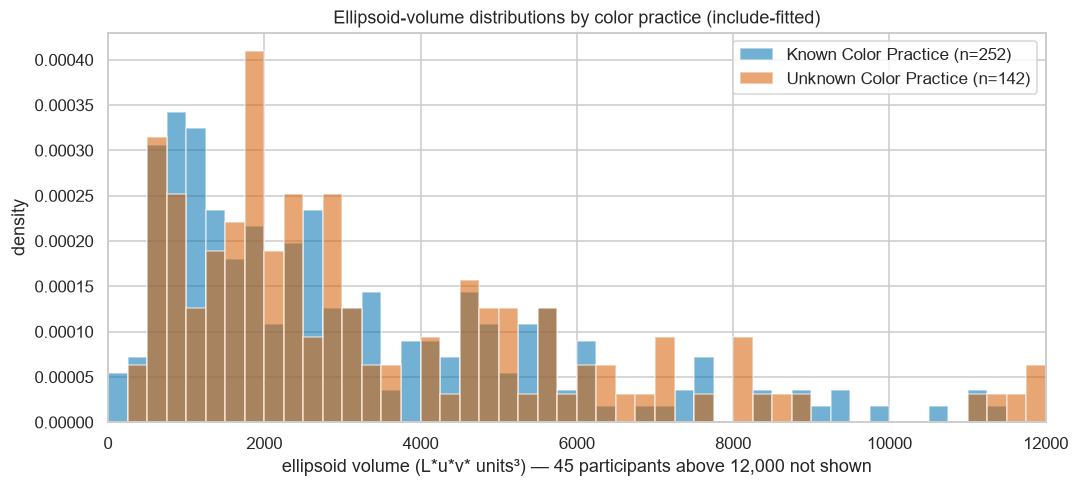

In [17]:
expert_volumes = analysis["expertDf"]["ellipsoidVolume"].to_numpy()
non_expert_volumes = analysis["nonExpertDf"]["ellipsoidVolume"].to_numpy()

bins = np.arange(0, HISTOGRAM_MAX_VOLUME + HISTOGRAM_BIN_WIDTH, HISTOGRAM_BIN_WIDTH)
visible_expert = expert_volumes[expert_volumes <= HISTOGRAM_MAX_VOLUME]
visible_non_expert = non_expert_volumes[non_expert_volumes <= HISTOGRAM_MAX_VOLUME]
n_omitted = (len(expert_volumes) - len(visible_expert)) + (
    len(non_expert_volumes) - len(visible_non_expert)
)

fig, ax = plt.subplots(figsize=(11, 4.6))
ax.hist(visible_expert, bins=bins, density=True, alpha=0.55, color=EXPERT_COLOR,
        label=f"Known Color Practice (n={len(expert_volumes)})")
ax.hist(visible_non_expert, bins=bins, density=True, alpha=0.55, color=NON_EXPERT_COLOR,
        label=f"Unknown Color Practice (n={len(non_expert_volumes)})")
ax.set_xlim(0, HISTOGRAM_MAX_VOLUME)
ax.set_xlabel(f"ellipsoid volume (L*u*v* units³) — {n_omitted} participants above "
              f"{HISTOGRAM_MAX_VOLUME:,} not shown")
ax.set_ylabel("density")
ax.set_title("Ellipsoid-volume distributions by color practice (include-fitted)")
ax.legend()
plt.show()

### 8. Welch's t-tests

Welch two-sample t-tests (Known − Unknown) on the per-participant metrics. Given the imbalanced group sizes, treat these as descriptive context; none of the contrasts reach significance.

In [18]:
def welch_table(result: dict, mode_label: str) -> pd.DataFrame:
    table = result["comparisons"].copy()
    table.insert(0, "mode", mode_label)
    table["expert (mean ± SD)"] = table["expert"].map(
        lambda s: f"{s['mean']:.4f} ± {s['sd']:.4f}"
    )
    table["non-expert (mean ± SD)"] = table["nonExpert"].map(
        lambda s: f"{s['mean']:.4f} ± {s['sd']:.4f}"
    )
    return table[
        ["mode", "label", "expert (mean ± SD)", "non-expert (mean ± SD)",
         "delta", "t", "df", "p"]
    ]

welch_all = pd.concat(
    [welch_table(analysis, "include-fitted"), welch_table(analysis_exact, "exact")],
    ignore_index=True,
)
welch_all.style.format({"delta": "{:+.4f}", "t": "{:.3f}", "df": "{:.1f}", "p": "{:.3f}"}).hide(axis="index")

mode,label,expert (mean ± SD),non-expert (mean ± SD),delta,t,df,p
include-fitted,Trial accuracy,0.5997 ± 0.0740,0.6029 ± 0.0685,-0.0031,-0.421,311.5,0.674
include-fitted,Mean raw threshold,16.1683 ± 9.2243,16.4378 ± 7.6324,-0.2695,-0.312,339.4,0.756
include-fitted,Mean normalized threshold,0.1140 ± 0.0614,0.1161 ± 0.0513,-0.0021,-0.365,336.9,0.715
exact,Trial accuracy,0.5970 ± 0.0560,0.5971 ± 0.0715,-0.0001,-0.009,168.6,0.993
exact,Mean raw threshold,15.4909 ± 5.9188,16.7231 ± 7.9724,-1.2322,-1.299,162.0,0.196
exact,Mean normalized threshold,0.1100 ± 0.0397,0.1179 ± 0.0532,-0.0079,-1.251,162.7,0.213


### 9. Normality diagnostics

The Welch tests above assume approximate normality of each group's metric. Shapiro–Wilk tests and Q–Q plots (Blom plotting positions, standardized so the reference line is $y = x$) per group and pooled. Accuracy and thresholds are close to normal; ellipsoid volume is strongly right-skewed, which is why the volume comparison is made on distribution summaries rather than a t-test on raw volumes.

variable,group,n,W,p,verdict (α=0.05)
Trial accuracy,Known,252,0.9317,0.0000,reject
Trial accuracy,Unknown,142,0.9825,0.0673,fail-to-reject
Trial accuracy,Pooled,394,0.9539,0.0000,reject
Mean raw threshold,Known,252,0.6149,0.0000,reject
Mean raw threshold,Unknown,142,0.7893,0.0000,reject
Mean raw threshold,Pooled,394,0.6682,0.0000,reject
Mean normalized threshold,Known,252,0.6202,0.0000,reject
Mean normalized threshold,Unknown,142,0.7831,0.0000,reject
Mean normalized threshold,Pooled,394,0.6711,0.0000,reject
Ellipsoid volume,Known,252,0.0817,0.0000,reject


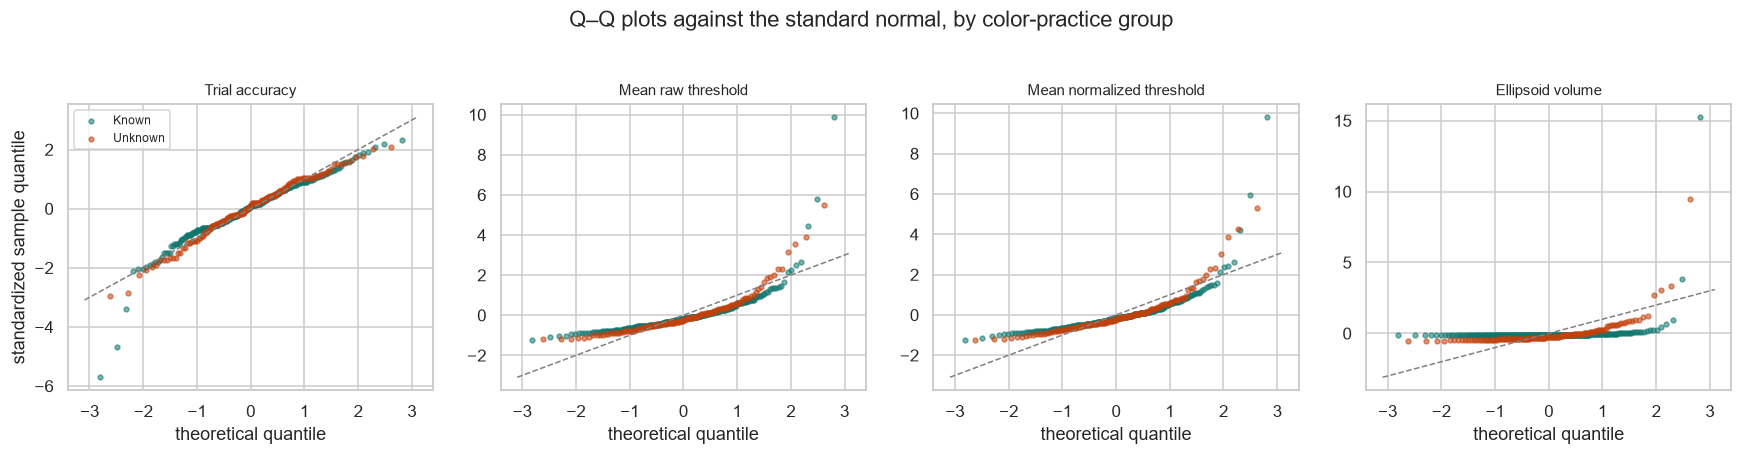

In [19]:
normality_rows = []
for variable in analysis["normality"]:
    for group in ("expert", "nonExpert", "pooled"):
        result = variable[group]
        normality_rows.append(
            {
                "variable": variable["label"],
                "group": {"expert": "Known", "nonExpert": "Unknown", "pooled": "Pooled"}[group],
                "n": result["n"],
                "W": result["W"],
                "p": result["p"],
                "verdict (α=0.05)": result["verdict"],
            }
        )
normality_table = pd.DataFrame(normality_rows)
display(
    normality_table.style.format({"W": "{:.4f}", "p": "{:.4f}"}, na_rep="—").hide(axis="index")
)

fig, axs = plt.subplots(1, 4, figsize=(16, 4))
for ax, variable in zip(axs, analysis["normality"]):
    for group, color, label in [
        ("expert", NORMALITY_EXPERT_COLOR, "Known"),
        ("nonExpert", NORMALITY_NON_EXPERT_COLOR, "Unknown"),
    ]:
        theoretical, sample = variable["qq"][group]
        ax.scatter(theoretical, sample, s=10, alpha=0.55, color=color, label=label)
    lims = ax.get_xlim()
    ax.plot(lims, lims, color="gray", linewidth=1, linestyle="--")
    ax.set_title(variable["label"], fontsize=10)
    ax.set_xlabel("theoretical quantile")
axs[0].set_ylabel("standardized sample quantile")
axs[0].legend(fontsize=8)
fig.suptitle("Q–Q plots against the standard normal, by color-practice group", y=1.03)
fig.tight_layout()
plt.show()

## Conclusions

**Replication (Part A).** Our results reproduce the key findings of Reinecke et al. (2016): the reconstructed ellipsoid-volume distribution is strongly right-skewed, with most participants (~60%) producing small discrimination volumes (≤ 3,000) and a minority producing much larger ones. Our participants' median volume is roughly 60% larger than the original study's, a moderate upward shift on the log scale (Cohen's d ≈ 0.52), consistent with the paper's *Replication Differences*: the perceptual pattern replicates while absolute thresholds shift with uncontrolled crowdsourcing factors.

**Extension (Part B).** Splitting participants by self-reported color practice shows no significant differences: Welch's t-tests on trial accuracy and on raw/normalized thresholds are all non-significant in both ellipse modes (accuracy p ≈ 0.67 in the fitted-fallback analysis that retains all 394 participants), and the two groups' volume distributions overlap almost completely. Together with Experiment 1, this indicates that self-reported color-related practice does not measurably affect color discrimination in these tasks.